In [ ]:
from __future__ import annotations
import itertools
import typing
from pathlib import Path

%matplotlib inline

import numpy as np
from scipy.signal import sawtooth
import matplotlib.pyplot as plt
from PIL import Image

if typing.TYPE_CHECKING:
    from os import PathLike
    from numpy.typing import NDArray

In [ ]:
def plot_bitmap(
    bitmap: NDArray[np.uint8],
    dwell_time_cmap: str = "plasma",
    ax: plt.axis.Axes | None = None,
) -> plt.axis.Axes:
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(20, 10), squeeze=True, dpi=300)
    x_size = bitmap.shape[1]
    ax.imshow(
        bitmap[:, :, 2],
        cmap=dwell_time_cmap,
        vmin=0,
        vmax=255,
        extent=(0, x_size, 5, 10),
        interpolation="none",
        aspect="auto",
    )
    ax.imshow(
        bitmap[:, :, 1],
        cmap="Greys_r",  # reversed as 0 is blanked
        vmin=0,
        vmax=1,
        extent=(0, x_size, 0, 5),
        interpolation="none",
        aspect="auto",
    )
    ax.set_xlim(0, x_size)
    ax.set_ylim(0, 10)
    return ax


In [3]:
def tile_min_max_with_varied_spacing(
    values,
    min_repeats: int = 1,
    max_repeats: int = 10,
    tiles: int = 3,
) -> NDArray[np.uint8]:
    arr = np.concatenate(
        [np.repeat(values, repeats=i) for i in range(min_repeats, max_repeats + 1)],
    ).astype(np.uint8)
    if tiles > 1:
        arr = np.tile(
            arr,
            reps=tiles,
        )
    return arr

In [4]:
def tile_cycle(
    values,
    min_repeats: int = 1,
    max_repeats: int = 16,
    repeats_step: int = 2,
    tiles: int = 3,
) -> NDArray[np.uint8]:
    arr = np.concatenate(
        [
            np.repeat(values, repeats=i)
            for i in range(min_repeats, max_repeats + 1, repeats_step)
        ],
    ).astype(np.uint8)
    if tiles > 1:
        arr = np.tile(
            arr,
            reps=tiles,
        )
    return arr


In [5]:
def create_dwell_time_cycling_bitmap(
    min_value: int, max_pixels: int = 16, repeats: int = 3
) -> NDArray[np.uint8]:
    arr = tile_cycle((255, min_value), max_repeats=max_pixels, tiles=repeats)
    bitmap_arr = np.zeros((1, arr.shape[0], 3), dtype=arr.dtype)
    bitmap_arr[:, :, 1] = 1  # Set blanking off
    bitmap_arr[:, :, 2] = arr
    return bitmap_arr


In [ ]:
def create_blanking_cycling_bitmap(
    min_pixels: int = 1,
    max_pixels: int = 16,
    repeats: int = 3,
    start_on: bool = True,
    dwell_time_value: int = 255,
) -> NDArray[np.uint8]:
    arr = tile_cycle(
        (1 - start_on, start_on),
        min_repeats=min_pixels,
        max_repeats=max_pixels,
        tiles=repeats,
    )
    bitmap_arr = np.zeros((1, arr.shape[0], 3), dtype=arr.dtype)
    bitmap_arr[:, :, 2] = dwell_time_value  # Set dwell time full
    bitmap_arr[:, :, 1] = arr
    return bitmap_arr

In [7]:
def create_wave_cycling_bitmap(
    min_value: int,
    min_cycle_pixels: int = 50,
    max_cycle_pixels: int = 550,
    cycle_pixels_step_size: int = 100,
    repeats: int = 3,
    wave_function=np.cos,
) -> NDArray[np.uint8]:
    arr = wave_function(
        [
            j
            for i in range(
                min_cycle_pixels, max_cycle_pixels + 1, cycle_pixels_step_size
            )
            for j in np.linspace(0, 2 * np.pi, endpoint=False, num=i, dtype=np.float64)
        ]
    )
    arr += 1
    arr /= 2
    arr = np.round((255 - min_value) * arr).astype(np.uint8)
    arr += min_value

    arr = np.tile(arr, reps=repeats)

    bitmap_arr = np.zeros((1, arr.shape[0], 3), dtype=arr.dtype)
    bitmap_arr[:, :, 1] = 1  # Set blanking off
    bitmap_arr[:, :, 2] = arr  # Set dwell time
    return bitmap_arr


In [8]:
def create_linear_ramp_bitmap(
    start_value: int,
    end_value: int,
    count: int = 512,
    repeats: int = 2,
) -> NDArray[np.uint8]:
    arr = np.linspace(start_value, end_value, endpoint=True, num=count, dtype=np.uint8)
    arr = np.tile(arr, reps=repeats)

    bitmap_arr = np.zeros((1, arr.shape[0], 3), dtype=arr.dtype)
    bitmap_arr[:, :, 1] = 1  # Set blanking off
    bitmap_arr[:, :, 2] = arr  # Set dwell time
    return bitmap_arr


In [ ]:
def create_test_bitmaps(
    pixel_size: float,
    pattern_width: float,
    pattern_height: float,
    save_directory: str | PathLike[str],
) -> None:
    save_directory = Path(save_directory)

    height_px = round(pattern_height / pixel_size)
    width_px = round(pattern_width / pixel_size)
    cycle_repeats = 3

    all_bitmaps: dict[str, NDArray[np.uint8]] = {
        "dwell_cosine_with_zeros": np.tile(
            create_wave_cycling_bitmap(
                0,
                repeats=cycle_repeats,
                min_cycle_pixels=width_px // cycle_repeats,
                max_cycle_pixels=width_px // cycle_repeats,
                cycle_pixels_step_size=1,
            ),
            reps=(height_px, 1, 1),
        ),
        "dwell_sawtooth_with_zeros": np.tile(
            create_wave_cycling_bitmap(
                0,
                repeats=cycle_repeats,
                wave_function=sawtooth,
                min_cycle_pixels=width_px // cycle_repeats,
                max_cycle_pixels=width_px // cycle_repeats,
                cycle_pixels_step_size=1,
            ),
            reps=(height_px, 1, 1),
        ),
        "dwell_inverted_sawtooth_with_zeros": np.tile(
            create_wave_cycling_bitmap(
                0,
                repeats=cycle_repeats,
                wave_function=lambda x: sawtooth(x, width=0),
                min_cycle_pixels=width_px // cycle_repeats,
                max_cycle_pixels=width_px // cycle_repeats,
                cycle_pixels_step_size=1,
            ),
            reps=(height_px, 1, 1),
        ),
        "long_linear_ramp_up": np.tile(
            create_linear_ramp_bitmap(0, 255, count=width_px, repeats=1),
            reps=(height_px, 1, 1),
        ),
        "long_linear_ramp_down": np.tile(
            create_linear_ramp_bitmap(255, 0, count=width_px, repeats=1),
            reps=(height_px, 1, 1),
        ),
        "all_full": np.full(
            (height_px, width_px, 3), fill_value=(0, 1, 255), dtype=np.uint8
        ),
        "all_half": np.full(
            (height_px, width_px, 3), fill_value=(0, 1, 127), dtype=np.uint8
        ),
        "all_ones": np.full(
            (height_px, width_px, 3), fill_value=(0, 1, 1), dtype=np.uint8
        ),
        "all_zeros": np.full(
            (height_px, width_px, 3), fill_value=(0, 1, 0), dtype=np.uint8
        ),
    }

    num_bitmaps = len(all_bitmaps)
    nrows = int(np.round(np.sqrt(len(all_bitmaps))))
    ncols = int(np.ceil(num_bitmaps / nrows))
    fig, axs = plt.subplots(
        nrows,
        ncols,
        # sharex=True,
        sharey=True,
        squeeze=True,
        figsize=(5 * ncols, 2 * nrows),
        dpi=300,
    )
    dwell_time_cmap = "plasma"

    # Create colourbar for all plots
    im = axs.flat[0].imshow(((0, 255),), vmin=0, vmax=255, cmap=dwell_time_cmap)
    axs.flat[0].clear()

    for ax, bitmap_info in itertools.zip_longest(axs.flat, all_bitmaps.items()):
        if bitmap_info is None:
            ax.set_axis_off()
        else:
            name, bitmap = bitmap_info

            ax.set_title(name)
            ax.set_xticks([0, bitmap.shape[1]])
            ax.set_yticks([])

            plot_bitmap(bitmap, dwell_time_cmap, ax=ax)
            fig.canvas.draw()

            Image.fromarray(bitmap).save(save_directory / f"{name}.bmp", format="BMP")
    fig.tight_layout()

    fig.colorbar(im, ax=axs.ravel().tolist())

    fig.savefig(save_directory / "bitmap_summary.png")
    fig.canvas.draw()


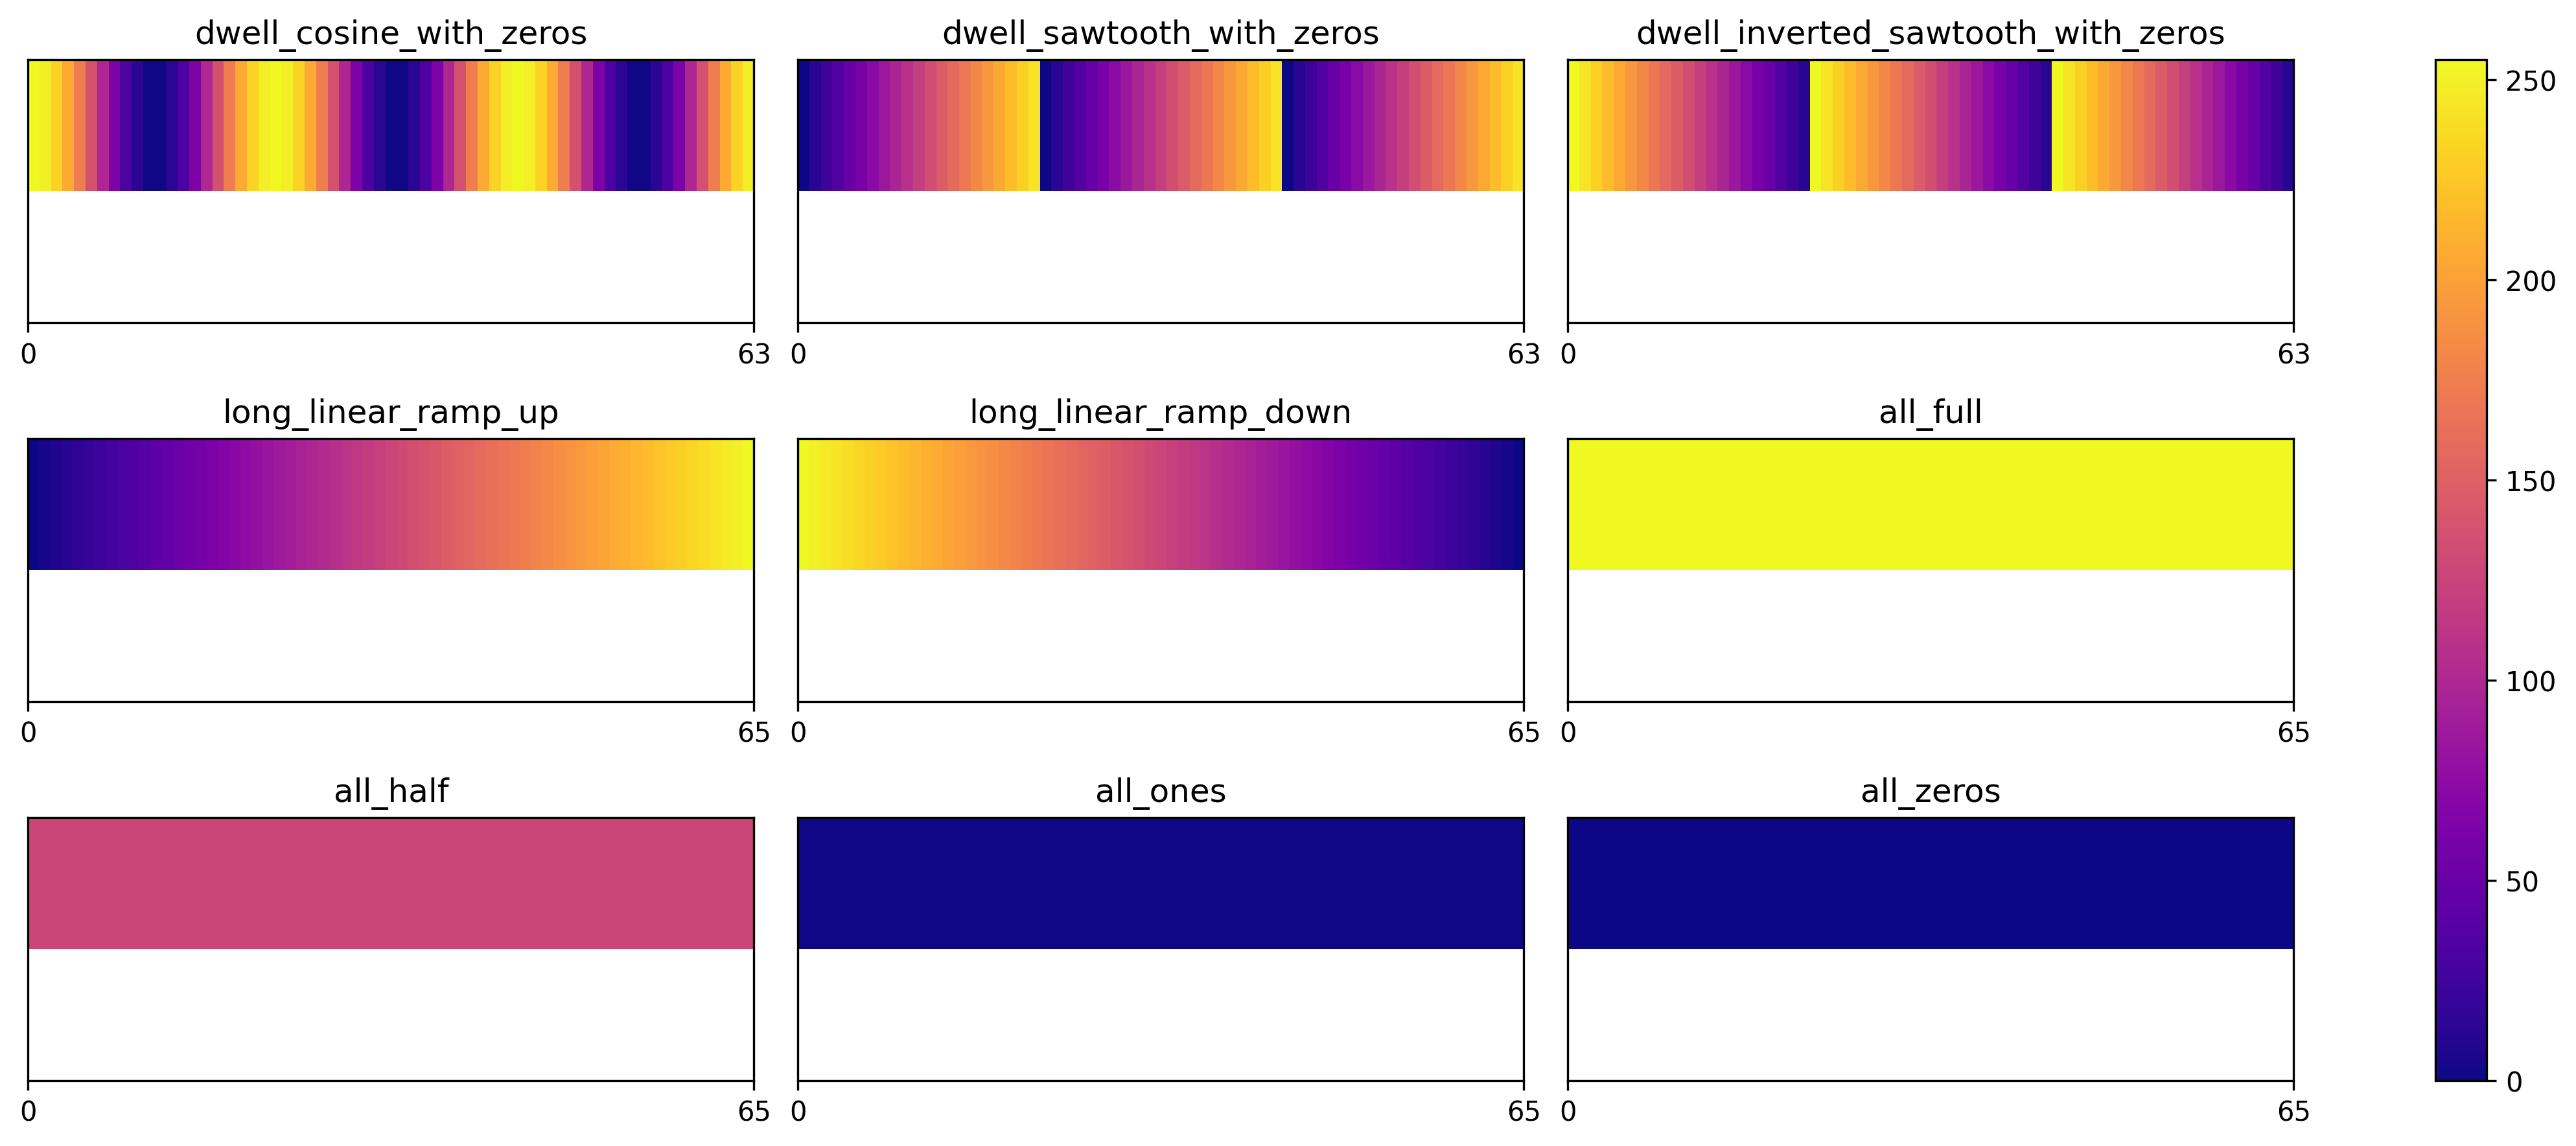

In [ ]:
test_bitmaps_dir = Path.cwd().parent.parent / "test_bitmaps"
test_bitmaps_dir.mkdir(exist_ok=True)

create_test_bitmaps(
    pixel_size=153e-9,
    pattern_width=1e-5,
    pattern_height=5e-6,
    save_directory=test_bitmaps_dir,
)